<a href="https://colab.research.google.com/github/MartinCarossino/analisis-ventas-videojuegos/blob/main/notebook/analisis_ventas_videojuegos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# BLOQUE 1 — CARGA DE DATOS
# ============================================
import pandas as pd

# URL "raw" del CSV en tu repo de GitHub.
URL_DATASET = "https://raw.githubusercontent.com/MartinCarossino/analisis-ventas-videojuegos/main/vgsales.csv"

# Leemos el CSV directo desde la URL
df = pd.read_csv(URL_DATASET)

# Primer vistazo: filas y columnas
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")

# .info() nos da de un saque: nombres de columnas, cantidad de valores
# no nulos por columna, y el tipo de dato (dtype) que Pandas infirió.
# Es el primer chequeo que recomienda tu material de la diplomatura.
df.info()

Dimensiones del dataset: 16598 filas x 11 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [2]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 1: nulos en Year)
# ============================================

# Decisión: para AÑO, no tiene sentido "inventar" un valor con la media o
# la moda — sería un dato falso. Como son pocas filas (271 de 16598, ~1.6%),
# las eliminamos en vez de rellenarlas.
# subset=['Year'] le dice a dropna que SOLO mire esa columna para decidir
# si borra la fila (no le importa si faltan otras columnas).
df = df.dropna(subset=['Year'])

print(f"Filas después de eliminar nulos en Year: {df.shape[0]}")
print(f"Nulos restantes en Year: {df['Year'].isnull().sum()}")

Filas después de eliminar nulos en Year: 16327
Nulos restantes en Year: 0


In [3]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 2: nulos en Publisher)
# ============================================

# Decisión distinta a la de Year: aquí SÍ tiene sentido rellenar, porque
# "Publisher desconocido" es una etiqueta honesta (no inventa un dato falso
# como pasaría con el año). Esto nos permite CONSERVAR esas 58 filas y
# toda su información válida en las demás columnas (ventas, género, etc.).
df['Publisher'] = df['Publisher'].fillna('Desconocido')

print(f"Nulos restantes en Publisher: {df['Publisher'].isnull().sum()}")
print(f"Filas totales (no se perdió ninguna): {df.shape[0]}")

Nulos restantes en Publisher: 0
Filas totales (no se perdió ninguna): 16327


In [4]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 3: convertir Year a entero)
# ============================================

# Ahora que Year no tiene NaN, podemos convertirla de float64 a int64.
# astype() fuerza la conversión de tipo de una columna completa.
df['Year'] = df['Year'].astype(int)

print(df['Year'].dtype)
print(df[['Name', 'Year']].head(3))

int64
                Name  Year
0         Wii Sports  2006
1  Super Mario Bros.  1985
2     Mario Kart Wii  2008


In [5]:
# ============================================
# BLOQUE 2 — LIMPIEZA (paso 4: verificar duplicados)
# ============================================

# df.duplicated() devuelve True en cada fila que sea una copia exacta
# de una fila anterior. .sum() cuenta cuántos True hay.
print(f"Filas duplicadas: {df.duplicated().sum()}")

Filas duplicadas: 0


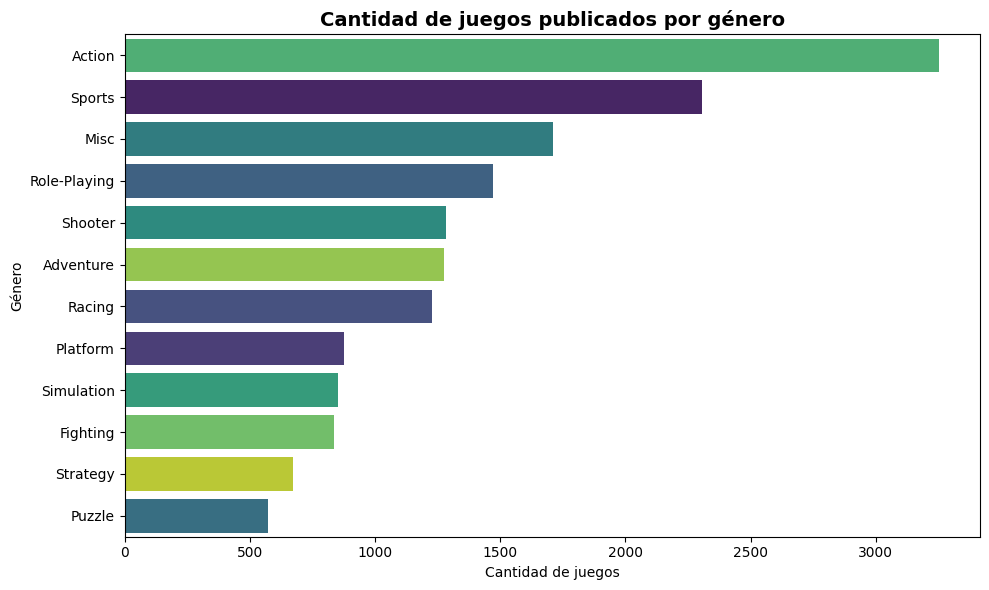

In [9]:
# ============================================
# BLOQUE 3 — EDA (paso 1: cantidad de juegos por género)
# ============================================
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y='Genre',
    hue='Genre',        # le decimos explícitamente que el color depende de Genre
    order=df['Genre'].value_counts().index,
    palette='viridis',
    legend=False         # no necesitamos leyenda: el eje Y ya dice qué es cada barra
)

plt.title('Cantidad de juegos publicados por género', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de juegos')
plt.ylabel('Género')
plt.tight_layout()
plt.show()

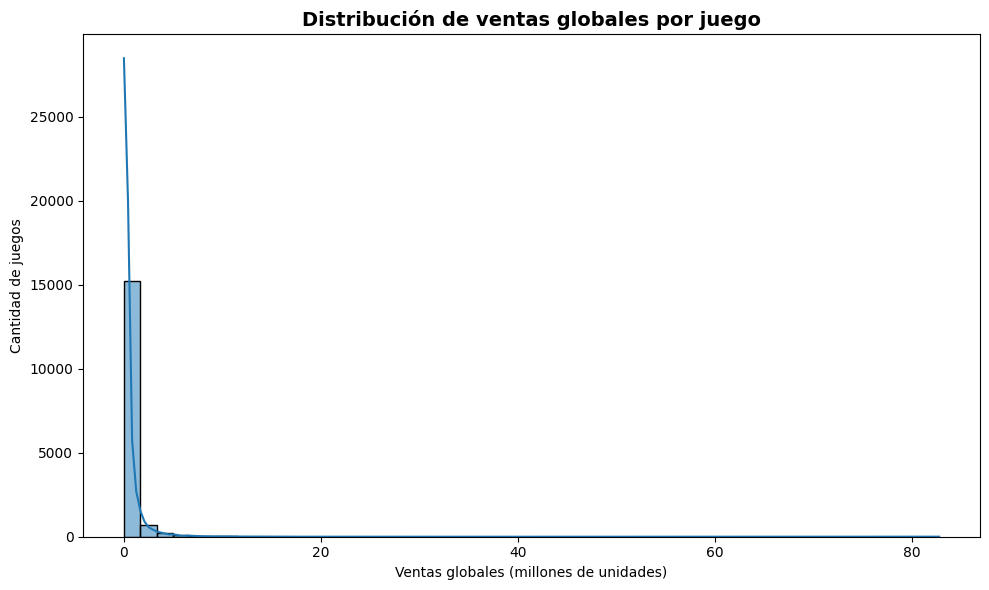

In [10]:
# ============================================
# BLOQUE 3 — EDA (paso 2: distribución de ventas globales)
# ============================================
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Global_Sales',
    bins=50,
    kde=True  # superpone la curva de densidad suavizada, como vimos en el material
)

plt.title('Distribución de ventas globales por juego', fontsize=14, fontweight='bold')
plt.xlabel('Ventas globales (millones de unidades)')
plt.ylabel('Cantidad de juegos')
plt.tight_layout()
plt.show()

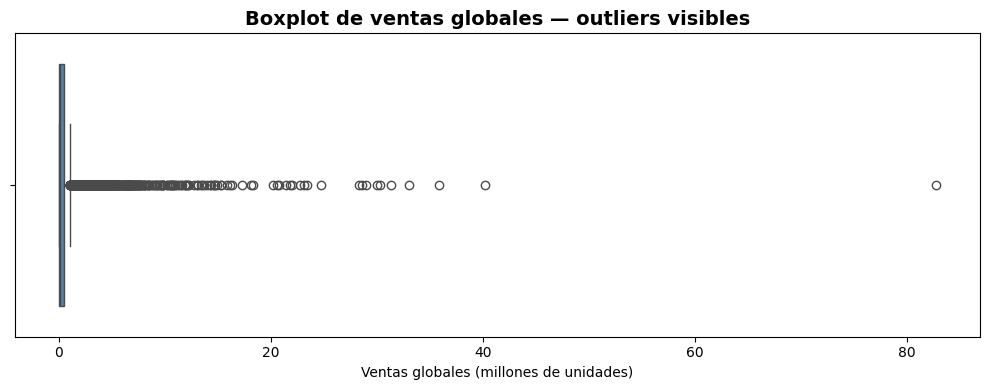

count    16327.000000
mean         0.540232
std          1.565732
min          0.010000
25%          0.060000
50%          0.170000
75%          0.480000
max         82.740000
Name: Global_Sales, dtype: float64


In [11]:
# ============================================
# BLOQUE 3 — EDA (paso 2b: boxplot para ver outliers)
# ============================================
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Global_Sales'], color='steelblue')

plt.title('Boxplot de ventas globales — outliers visibles', fontsize=14, fontweight='bold')
plt.xlabel('Ventas globales (millones de unidades)')
plt.tight_layout()
plt.show()

# Y los números concretos detrás del boxplot:
print(df['Global_Sales'].describe())

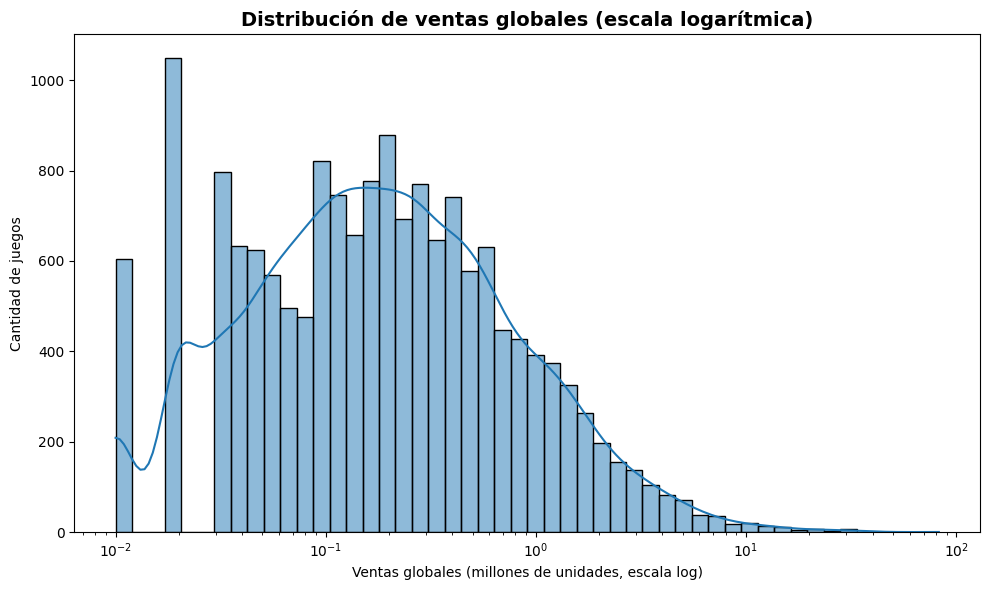

In [12]:
# ============================================
# BLOQUE 3 — EDA (paso 2c: histograma en escala log)
# ============================================
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='Global_Sales',
    bins=50,
    kde=True,
    log_scale=True  # la clave: cada "paso" en el eje X multiplica, no suma
)

plt.title('Distribución de ventas globales (escala logarítmica)', fontsize=14, fontweight='bold')
plt.xlabel('Ventas globales (millones de unidades, escala log)')
plt.ylabel('Cantidad de juegos')
plt.tight_layout()
plt.show()

Ventas globales totales por género (millones de unidades):
Genre
Action          1722.88
Sports          1309.24
Shooter         1026.20
Role-Playing     923.84
Platform         829.15
Misc             797.62
Racing           726.77
Fighting         444.05
Simulation       390.16
Puzzle           242.22
Adventure        234.80
Strategy         173.43
Name: Global_Sales, dtype: float64


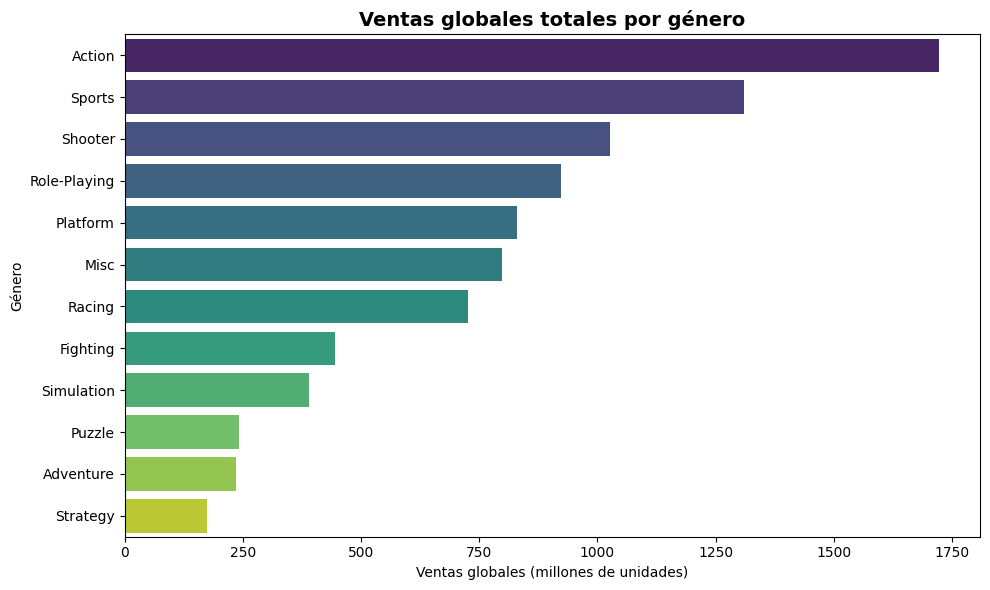

In [13]:
# ============================================
# BLOQUE 4 — PREGUNTA 1: Ventas globales por género
# ============================================

# Split: divide el dataset en grupos según 'Genre'
# Apply: suma 'Global_Sales' dentro de cada grupo
# Combine: arma una nueva Serie con un valor por género
ventas_por_genero = df.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=False)

print("Ventas globales totales por género (millones de unidades):")
print(ventas_por_genero.round(2))

# Visualización con Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(
    x=ventas_por_genero.values,
    y=ventas_por_genero.index,
    hue=ventas_por_genero.index,
    palette='viridis',
    legend=False
)
plt.title('Ventas globales totales por género', fontsize=14, fontweight='bold')
plt.xlabel('Ventas globales (millones de unidades)')
plt.ylabel('Género')
plt.tight_layout()
plt.show()

In [14]:
# ============================================
# BLOQUE 4 — PREGUNTA 2: Ventas por plataforma y región
# ============================================

# Agrupamos por plataforma y sumamos las 4 columnas de región a la vez.
# Como las 4 columnas ya son numéricas, .sum() directo sobre el groupby
# las suma todas en un solo paso (no necesitamos .agg() con diccionario aquí
# porque queremos la MISMA operación —suma— en todas).
ventas_por_plataforma_region = df.groupby('Platform')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()

# Nos quedamos con el Top 10 plataformas según ventas totales en NA, para no
# saturar el gráfico con las 31 plataformas (muchas con datos mínimos)
top10_plataformas = ventas_por_plataforma_region.sum(axis=1).sort_values(ascending=False).head(10).index
tabla_top10 = ventas_por_plataforma_region.loc[top10_plataformas]

print("Ventas por región — Top 10 plataformas:")
print(tabla_top10.round(2))

Ventas por región — Top 10 plataformas:
          NA_Sales  EU_Sales  JP_Sales  Other_Sales
Platform                                           
PS2         572.92    332.63    137.54       190.47
X360        594.33    278.01     12.30        84.67
PS3         388.90    340.47     79.21       140.81
Wii         497.37    264.35     68.28        79.20
DS          388.56    194.07    175.02        60.29
PS          334.71    212.38    139.78        40.69
GBA         184.12     74.59     46.56         7.61
PSP         107.09     67.16     75.89        41.52
PS4          96.80    123.70     14.30        43.36
GB          113.64     47.51     85.12         8.16


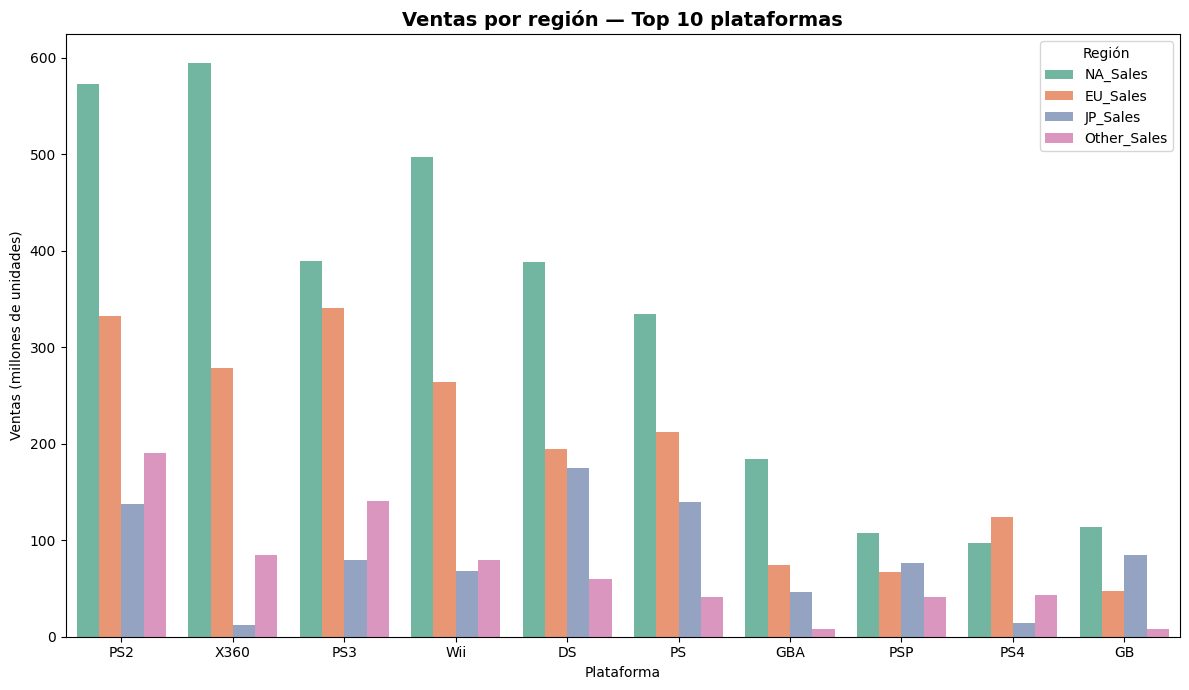

In [15]:
# ============================================
# BLOQUE 4 — PREGUNTA 2b: visualización de ventas por región
# ============================================

# Para graficar con hue por región, necesitamos "derretir" la tabla:
# pasar de formato ancho (una columna por región) a formato largo
# (una fila por cada combinación plataforma-región). Esto se hace con melt().
tabla_larga = tabla_top10.reset_index().melt(
    id_vars='Platform',
    var_name='Region',
    value_name='Ventas'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=tabla_larga,
    x='Platform',
    y='Ventas',
    hue='Region',
    order=top10_plataformas,  # mantenemos el mismo orden que ya calculamos
    palette='Set2'
)

plt.title('Ventas por región — Top 10 plataformas', fontsize=14, fontweight='bold')
plt.xlabel('Plataforma')
plt.ylabel('Ventas (millones de unidades)')
plt.legend(title='Región')
plt.tight_layout()
plt.show()

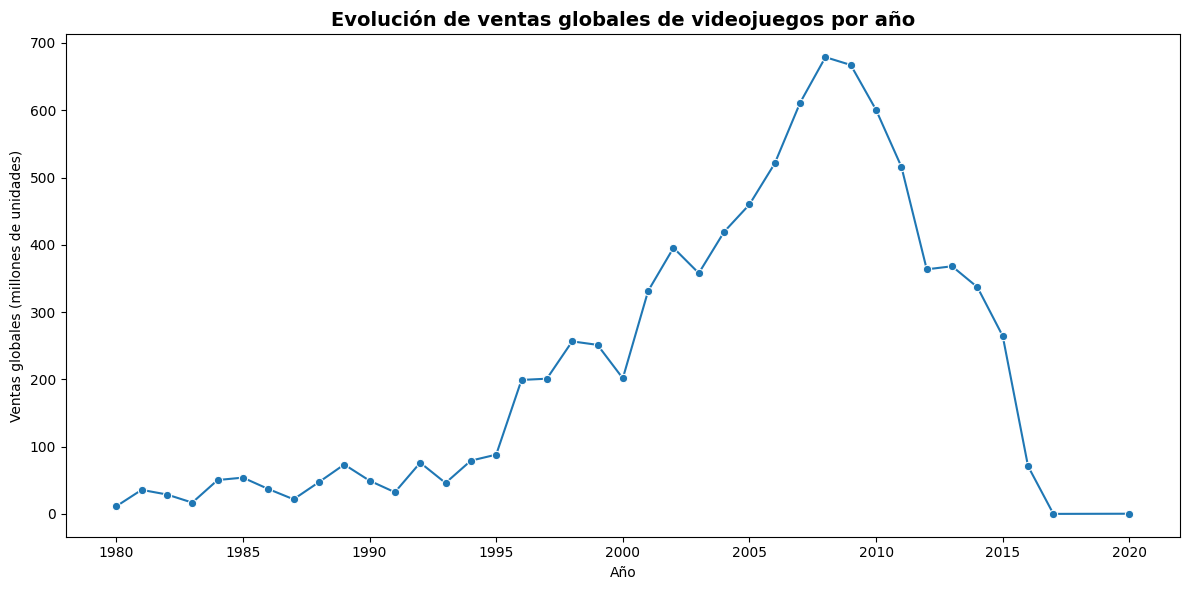

In [16]:
# ============================================
# BLOQUE 4 — PREGUNTA 3: Evolución de ventas globales por año
# ============================================

# Agrupamos por año y sumamos las ventas globales de todos los juegos
# lanzados ese año
ventas_por_anio = df.groupby('Year')['Global_Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ventas_por_anio,
    x='Year',
    y='Global_Sales',
    marker='o'
)

plt.title('Evolución de ventas globales de videojuegos por año', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones de unidades)')
plt.tight_layout()
plt.show()

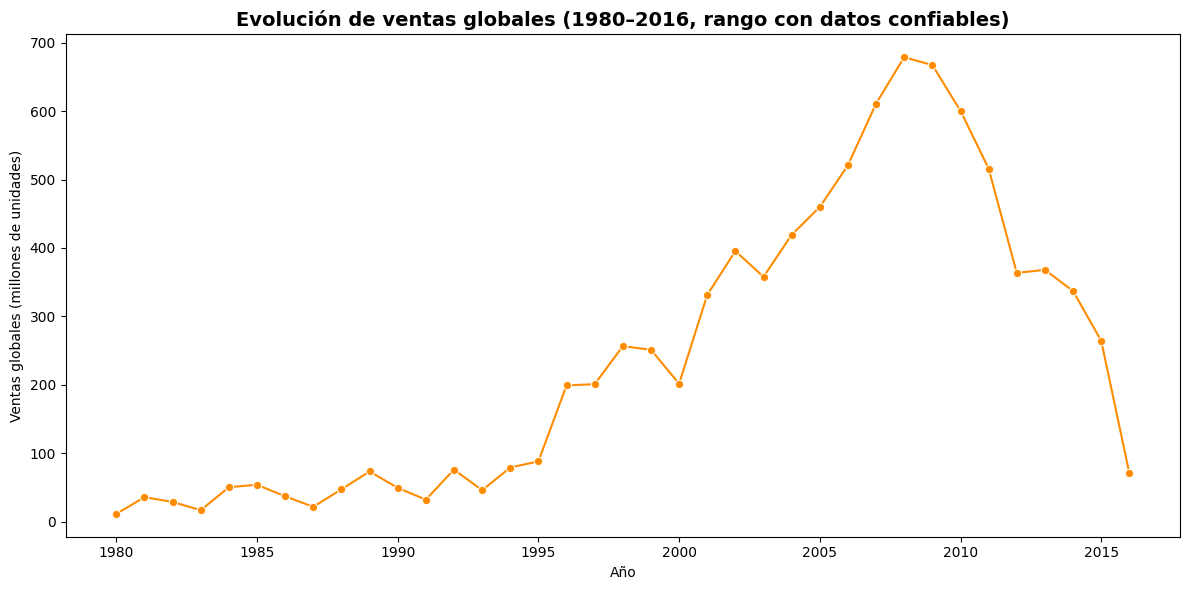

In [17]:
# ============================================
# BLOQUE 4 — PREGUNTA 3b: mismo gráfico, recortado a años confiables
# ============================================

# Filtramos años hasta 2016 — después de eso, el dataset pierde cobertura
df_anios_confiables = df[df['Year'] <= 2016]
ventas_por_anio_confiable = df_anios_confiables.groupby('Year')['Global_Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=ventas_por_anio_confiable,
    x='Year',
    y='Global_Sales',
    marker='o',
    color='darkorange'
)

plt.title('Evolución de ventas globales (1980–2016, rango con datos confiables)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones de unidades)')
plt.tight_layout()
plt.show()

In [18]:
# ============================================
# BLOQUE 4 — PREGUNTA 4: Publishers más exitosos (con .agg())
# ============================================

# .agg() con diccionario nos deja calcular VARIAS métricas distintas
# para el mismo grupo, en una sola operación — cada clave del diccionario
# define el nombre de la columna resultado, y la tupla indica
# (columna_original, función_de_agregación).
resumen_publishers = df.groupby('Publisher').agg(
    ventas_totales=('Global_Sales', 'sum'),
    cantidad_juegos=('Name', 'count'),
    venta_promedio_por_juego=('Global_Sales', 'mean')
).round(2)

# Nos quedamos con el Top 10 por ventas totales, para que el análisis
# tenga peso estadístico real (descartamos publishers con 1 o 2 juegos sueltos)
top10_publishers = resumen_publishers.sort_values('ventas_totales', ascending=False).head(10)

print("Top 10 publishers por ventas totales:")
print(top10_publishers)

Top 10 publishers por ventas totales:
                              ventas_totales  cantidad_juegos  \
Publisher                                                       
Nintendo                             1784.43              696   
Electronic Arts                      1093.39             1339   
Activision                            721.41              966   
Sony Computer Entertainment           607.28              682   
Ubisoft                               473.54              918   
Take-Two Interactive                  399.30              412   
THQ                                   340.44              712   
Konami Digital Entertainment          278.56              823   
Sega                                  270.70              632   
Namco Bandai Games                    253.65              928   

                              venta_promedio_por_juego  
Publisher                                               
Nintendo                                          2.56  
Electronic

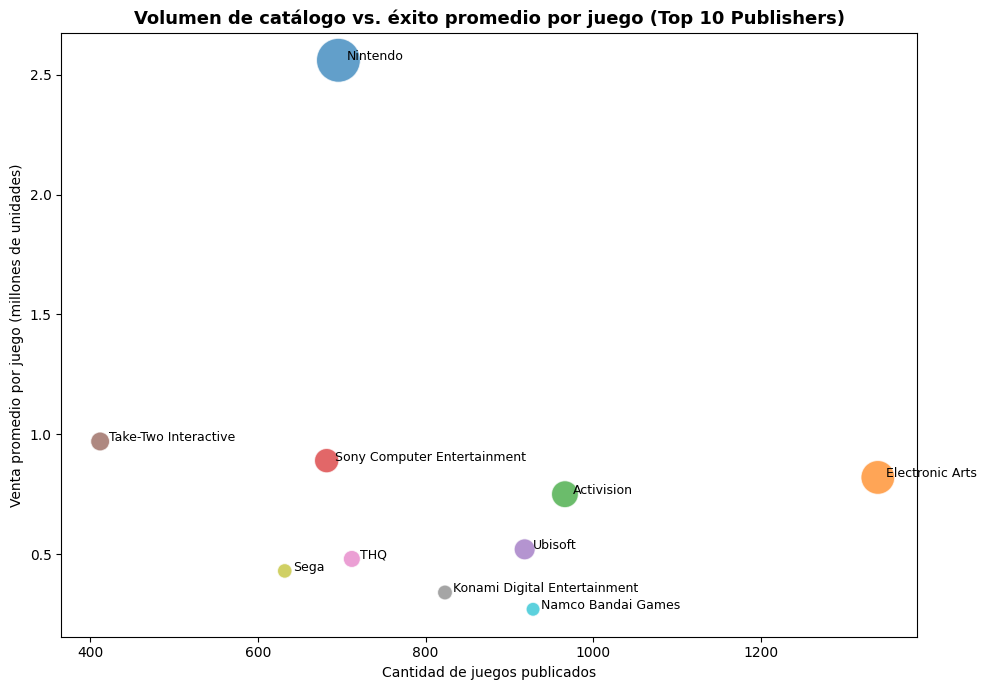

In [19]:
# ============================================
# BLOQUE 4 — PREGUNTA 4b: scatter de volumen vs. éxito promedio
# ============================================

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=top10_publishers.reset_index(),
    x='cantidad_juegos',
    y='venta_promedio_por_juego',
    size='ventas_totales',   # el tamaño del punto refuerza quién vendió más en total
    sizes=(100, 1000),       # rango de tamaños en píxeles
    hue='Publisher',
    legend=False,
    alpha=0.7
)

# Etiquetamos cada punto con el nombre del publisher, porque con leyenda
# desactivada (para no saturar) necesitamos otra forma de identificarlos
for _, fila in top10_publishers.reset_index().iterrows():
    plt.text(
        fila['cantidad_juegos'] + 10,
        fila['venta_promedio_por_juego'],
        fila['Publisher'],
        fontsize=9
    )

plt.title('Volumen de catálogo vs. éxito promedio por juego (Top 10 Publishers)', fontsize=13, fontweight='bold')
plt.xlabel('Cantidad de juegos publicados')
plt.ylabel('Venta promedio por juego (millones de unidades)')
plt.tight_layout()
plt.show()

## Conclusiones

**Sobre los datos:**
- El dataset original tenía nulos en `Year` (271 filas, 1.6%) y `Publisher` (58 filas, 0.3%).
  Los años faltantes se eliminaron (no existe un valor razonable para "inventar" un año),
  mientras que los publishers faltantes se etiquetaron como "Desconocido" para no perder
  el resto de la información de esas filas.
- Las ventas globales por juego están extremadamente sesgadas a la derecha: la mediana es
  de 0.17 millones de copias, pero el máximo (Wii Sports) llega a 82.74 millones — casi
  500 veces más que el juego "típico". Esto obligó a usar escala logarítmica para visualizar
  correctamente la distribución real.

**Sobre géneros y plataformas:**
- Action y Sports dominan tanto en cantidad de títulos publicados como en ventas totales.
- Shooter es un caso particular: con relativamente pocos títulos (5° lugar en cantidad),
  alcanza el 3er lugar en ventas totales — un género con menos volumen pero mayor "pegada"
  comercial por título, probablemente impulsado por franquicias muy fuertes.
- Existe un patrón regional marcado: las plataformas de Microsoft (Xbox 360) casi no
  tuvieron mercado en Japón, mientras que las plataformas portátiles de Nintendo y Sony
  mantuvieron una proporción de ventas japonesas mucho más alta.

**Sobre la evolución temporal:**
- Las ventas globales alcanzaron su pico histórico en 2008-2009, coincidiendo con la era
  de PS3, Xbox 360 y Wii.
- La caída abrupta a partir de 2016-2017 no representa un colapso real de la industria,
  sino una limitación de cobertura del dataset (scraping de vgchartz), que no capturó de
  forma confiable los años más recientes. Los gráficos finales se recortaron a 2016 para
  evitar una conclusión equivocada.

**Sobre publishers:**
- Nintendo se destaca con una estrategia claramente distinta al resto del Top 10: con menos
  juegos publicados que la mayoría de sus competidores, logra el promedio de ventas por
  juego más alto (2.56 millones, entre 3 y 9 veces el de los demás), resultando en el mayor
  volumen de ventas totales del grupo.
- En contraste, publishers como Namco Bandai Games o Konami apuestan por catálogos extensos
  con un promedio de ventas por título más moderado.

**Limitaciones:**
- El dataset no incluye notas de crítica, presupuesto de desarrollo, ni plataformas de
  distribución digital — solo ventas físicas reportadas por vgchartz, una fuente de
  scraping, no una fuente oficial de la industria.
- Próximo paso lógico: cruzar este dataset con datos de Metacritic para explorar si existe
  relación entre crítica especializada y ventas comerciales.